<a href="https://colab.research.google.com/github/doney25/CaseStudy/blob/main/Case_Study_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction
This project aims to predict customer churn using machine learning. The goal is to identify customers who are likely to leave the company based on their details and service usage.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data=pd.read_csv('/content/Training_data.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,5649-RXQTV,Male,0,No,No,51,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.00,5038.15,No
5630,3908-MKIMJ,Male,1,Yes,No,68,No,No phone service,DSL,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,41.95,2965.75,No
5631,4277-BWBML,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.95,1322.85,No
5632,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,NaN,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No


In [6]:
data.MonthlyCharges

,MonthlyCharges
0,20.75
1,35.75
2,98.60
3,20.45
4,51.25
...,...
5629,99.00
5630,41.95
5631,19.95
5632,82.45


In [7]:
data.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.value_counts(data['PaymentMethod'])

,count
PaymentMethod,
Electronic check,1892
Mailed check,1278
Bank transfer (automatic),1248
Credit card (automatic),1216


In [11]:
data.drop(columns=['customerID'],inplace=True)

In [12]:
data['gender']=data['gender'].fillna(data['gender'].mode()[0])

In [13]:
data['OnlineSecurity']=data['OnlineSecurity'].fillna(data['OnlineSecurity'].mode()[0])

In [14]:
data['MonthlyCharges']=data['MonthlyCharges'].fillna(data['MonthlyCharges'].mean())

In [15]:
data['TotalCharges']=pd.to_numeric(data['TotalCharges'],errors="coerce")

In [16]:
data['TotalCharges']=data['TotalCharges'].fillna(data['TotalCharges'].mean())

In [17]:
data.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [18]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.159744,32.606851,65.102052,2283.932279
std,0.366401,24.614976,28.986241,2207.600372
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,44.000000,446.062500
50%,0.000000,29.000000,68.925000,1526.350000
75%,0.000000,56.000000,89.100000,3590.537500
max,1.000000,72.000000,118.750000,8684.800000


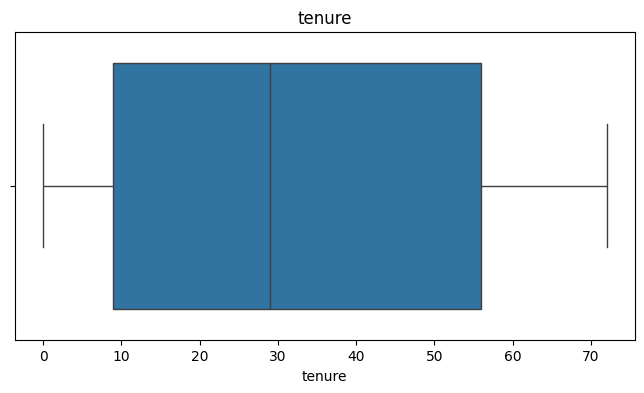

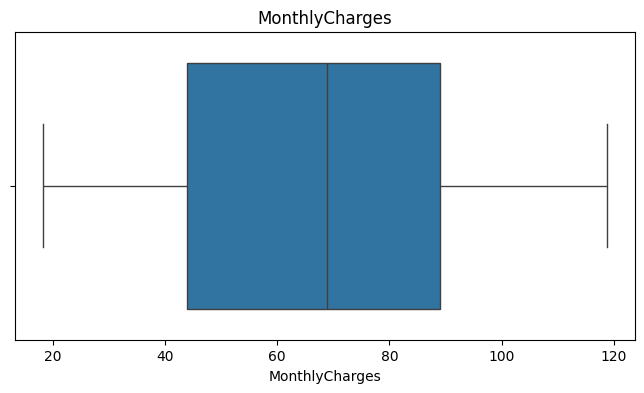

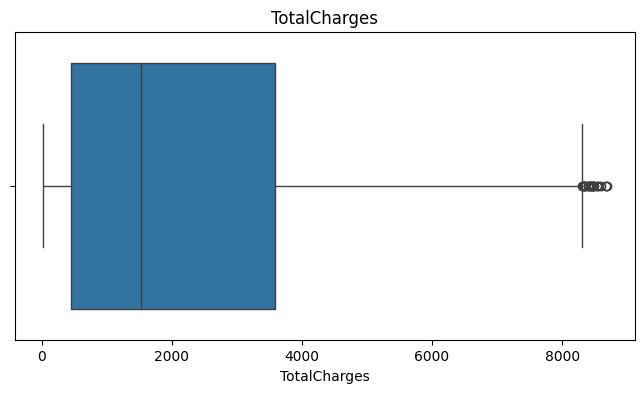

In [19]:
num_cols=['tenure',	'MonthlyCharges',	'TotalCharges']

for i in num_cols:
  plt.figure(figsize=(8,4))
  sns.boxplot(data=data,x=i)
  plt.title(i)
  plt.show()

#Encoding and Scaling

In [20]:
data['Churn']=data['Churn'].map({'No': 0, 'Yes': 1})

In [21]:
data['Churn']

,Churn
0,0
1,0
2,0
3,0
4,0
...,...
5629,0
5630,0
5631,0
5632,0


In [22]:
y = data['Churn']
X = data.drop(columns='Churn')

In [23]:
obj_cols = data.select_dtypes(include='object').columns.tolist()


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train = pd.get_dummies(X_train, columns=obj_cols, drop_first=True,dtype=int)
X_test = pd.get_dummies(X_test, columns=obj_cols, drop_first=True,dtype=int)

In [26]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4082,0,50,108.25,5431.40,1,1,1,1,0,1,...,0,1,0,1,1,0,1,0,1,0
1728,1,9,49.20,447.90,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2795,0,3,97.90,315.30,0,0,0,1,0,0,...,0,1,0,1,0,0,1,0,1,0
334,0,36,20.35,695.85,1,0,0,1,0,0,...,1,0,1,0,1,0,1,1,0,0
3625,1,30,40.30,1172.95,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,1,0


In [27]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()

X_train[num_cols]=std.fit_transform(X_train[num_cols])
X_test[num_cols]=std.transform(X_test[num_cols])

#Feature Engineering

In [28]:
X_train["Customer_Lifetime_Value"] = X_train["tenure"] * X_train["MonthlyCharges"]
X_test["Customer_Lifetime_Value"] = X_test["tenure"] * X_test["MonthlyCharges"]

In [29]:
X_train["Tenure_Contract_OneYear"] = X_train["tenure"] * X_train["Contract_One year"]
X_test["Tenure_Contract_OneYear"] = X_test["tenure"] * X_test["Contract_One year"]

X_train["Tenure_Contract_TwoYear"] = X_train["tenure"] * X_train["Contract_Two year"]
X_test["Tenure_Contract_TwoYear"] = X_test["tenure"] * X_test["Contract_Two year"]


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
import pandas as pd

feature_importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Feature,Importance
30,Customer_Lifetime_Value,0.145704
3,TotalCharges,0.141150
1,tenure,0.131386
2,MonthlyCharges,0.120471
10,InternetService_Fiber optic,0.041034
28,PaymentMethod_Electronic check,0.036716
32,Tenure_Contract_TwoYear,0.026156
4,gender_Male,0.024473
25,Contract_Two year,0.024309
31,Tenure_Contract_OneYear,0.022842


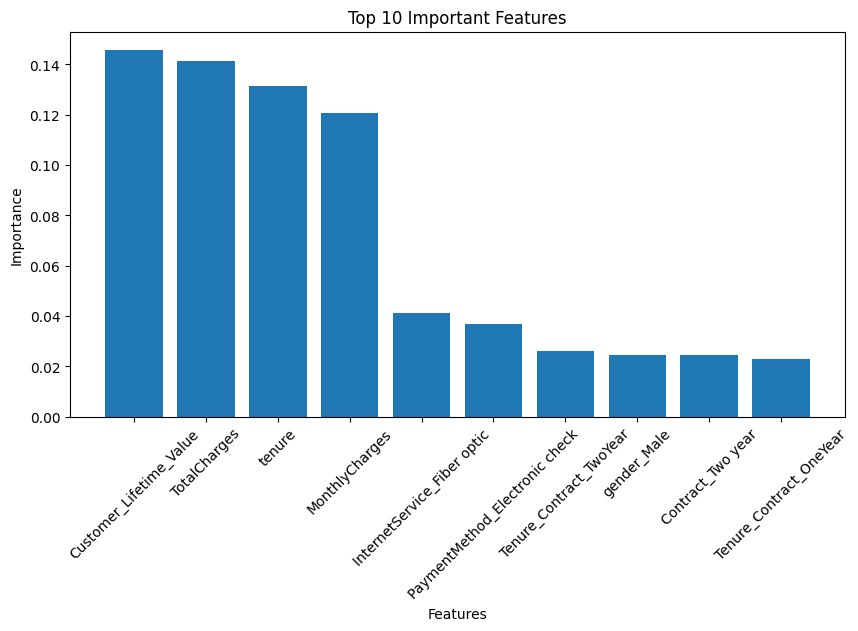

In [32]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Feature"], top10["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

#Model Development

###Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(class_weight='balanced',random_state=42,max_iter=100)
log_model.fit(X_train,y_train)
y_pred_log=log_model.predict(X_test)
y_pred_log

array([0, 0, 0, ..., 1, 1, 0])

In [34]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, ConfusionMatrixDisplay
print("Logistics Regression Accuracy:",accuracy_score(y_test,y_pred_log))

Logistics Regression Accuracy: 0.7409050576752441


####KNN

In [35]:
from sklearn.neighbors import KNeighborsClassifier

metric_k=[ ]
for i in np.arange(1,15):
  model_knn=KNeighborsClassifier(n_neighbors=i)
  model_knn.fit(X_train,y_train)
  y_pred_knn=model_knn.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred_knn)
  metric_k.append(accuracy)

metric_k

[0.7222715173025732,
 0.7320319432120674,
 0.74622892635315,
 0.74622892635315,
 0.7480035492457853,
 0.7497781721384206,
 0.743566992014197,
 0.7515527950310559,
 0.7551020408163265,
 0.7737355811889973,
 0.7675244010647737,
 0.774622892635315,
 0.7701863354037267,
 0.774622892635315]

In [36]:
model_knn=KNeighborsClassifier(n_neighbors=8)
model_knn.fit(X_train,y_train)
y_pred_knn=model_knn.predict(X_test)
print("KNN Accuracy:",accuracy_score(y_test,y_pred_knn))

KNN Accuracy: 0.7515527950310559


###Decison Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

model_dt=DecisionTreeClassifier(random_state=42,
                                max_depth=5,
                                min_samples_split=5,
                                min_samples_leaf=5,
                                criterion='entropy',
                                max_leaf_nodes=5,
                                class_weight='balanced'
                                )
model_dt.fit(X_train,y_train)
y_pred_dt=model_dt.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy: 0.6601597160603372


[Text(0.6666666666666666, 0.9, 'x[25] <= 0.5\nentropy = 1.0\nsamples = 4507\nvalue = [2253.5, 2253.5]'),
 Text(0.5, 0.7, 'x[24] <= 0.5\nentropy = 0.976\nsamples = 3414\nvalue = [1530.781, 2203.847]'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'x[10] <= 0.5\nentropy = 0.906\nsamples = 2453\nvalue = [950.304, 2005.233]'),
 Text(0.16666666666666666, 0.3, 'entropy = 0.999\nsamples = 1120\nvalue = [549.998, 588.202]'),
 Text(0.5, 0.3, 'x[1] <= -0.611\nentropy = 0.761\nsamples = 1333\nvalue = [400.306, 1417.031]'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.578\nsamples = 709\nvalue = [149.014, 933.866]'),
 Text(0.6666666666666666, 0.1, 'entropy = 0.927\nsamples = 624\nvalue = [251.292, 483.166]'),
 Text(0.6666666666666666, 0.5, 'entropy = 0.819\nsamples = 961\nvalue = [580.478, 198.614]'),
 Text(0.8333333333333334, 0.7, 'entropy = 0.344\nsamples = 1093\nvalue = [722.719, 49.653]'),
 Text(0.75, 0.8, '  False')]

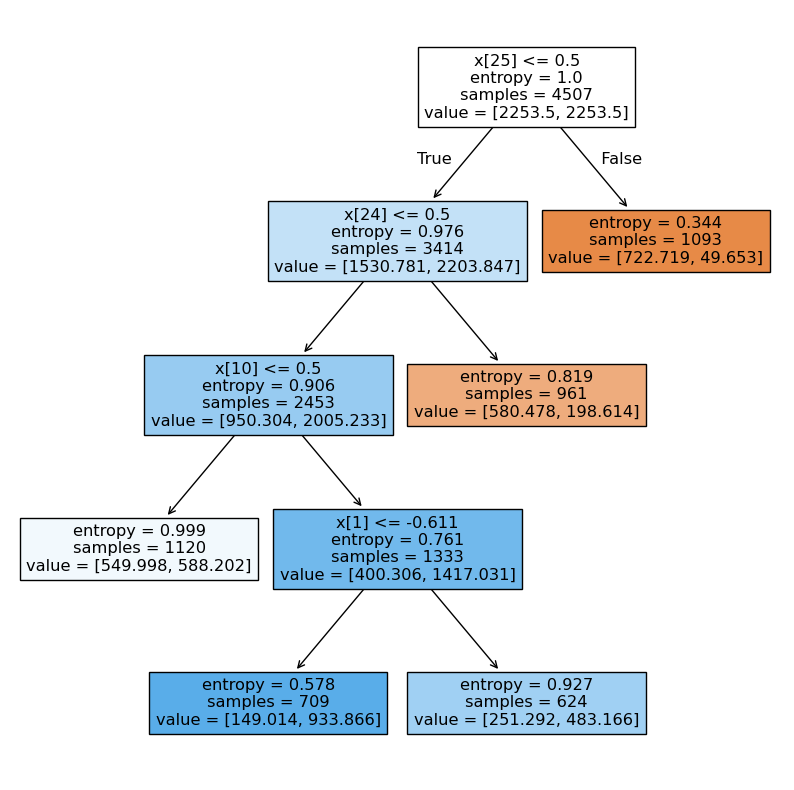

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names=X_train.columns.tolist()

plt.figure(figsize=(10,10))
plot_tree(model_dt,filled=True)

###Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(random_state=30,
                                n_estimators=200,
                                max_depth=10,
                                min_samples_split=15,
                                max_features='sqrt',
                                class_weight=None)
model_rf.fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.7897071872227152


In [40]:
from sklearn.model_selection import GridSearchCV
param_model= {
              'n_estimators':[100,200,300],
              'max_depth':[None,10,20],
              'min_samples_split':[2,5,10],
              'criterion':['gini','entropy'],
              'min_samples_leaf':[1,2,4],
              'max_features':['sqrt','log2']
}

grid=GridSearchCV(estimator=model_rf,
                  param_grid=param_model,
                  cv=5,
                  scoring='accuracy',
                  n_jobs=-1)
grid.fit(X_train,y_train)
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'n_estimators': 200}

In [42]:
grid.best_score_
best_model=grid.best_estimator_
y_pred_best=best_model.predict(X_test)
accuracy_score(y_test,y_pred_best)

0.7790594498669032

#Testing

In [43]:
test_data = pd.read_csv("Testing_data.csv")
test_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [44]:
test_data.drop("customerID", axis=1, inplace=True)

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

test_data["Churn"] = le.fit_transform(test_data["Churn"])

In [46]:
X_test = test_data.drop("Churn", axis=1)
y_test = test_data["Churn"]

In [47]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

binary_map = {
    'Male': 1,
    'Female': 0,
    'Yes': 1,
    'No': 0
}

for col in binary_cols:
    X_test[col] = X_test[col].map(binary_map)

In [48]:
multi_cat_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

X_test = pd.get_dummies(
    X_test,
    columns=multi_cat_cols,
    drop_first=True,
    dtype=int
)

In [49]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [50]:
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')

X_test['TotalCharges'] = X_test['TotalCharges'].fillna(X_test['TotalCharges'].median())

In [52]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_test[num_cols] = std.transform(X_test[num_cols])

In [ ]:
X_test["Customer_Lifetime_Value"] = X_test["tenure"] * X_test["MonthlyCharges"]

X_test["Tenure_Contract_OneYear"] = (
    X_test["tenure"] * X_test["Contract_One year"]
)

X_test["Tenure_Contract_TwoYear"] = (
    X_test["tenure"] * X_test["Contract_Two year"]
)

In [53]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

###Prediction

In [55]:
y_pred = log_model.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7281760113555713

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1044
           1       0.48      0.77      0.60       365

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.73      0.74      1409


Confusion Matrix

[[744 300]
 [ 83 282]]


#CONCLUSION
The project successfully predicted customer churn using machine learning. Logistic Regression performed the best in terms of accuracy, while the tuned Random Forest achieved better recall.

Business Recommendations Focus on customers with shorter tenure. Encourage long-term contracts. Provide offers to customers who are likely to churn.

